# Accessing GDEX THREDDS Data with Siphon

---

## Overview

Siphon is Unidata's Python library for accessing data from THREDDS Data Servers. This notebook shows how to use Siphon to browse the GDEX catalog and retrieve data via NCSS and CDMRemote.

1. Navigate the GDEX TDS catalog with Siphon
2. Submit an NCSS (NetCDF Subset Service) query
3. Access remote arrays via CDMRemote

:::{tip} What are NCSS and CDMRemote?
**NCSS (NetCDF Subset Service)** allows you to request a spatial, temporal, and variable subset of a dataset directly from the server — no need to download the full file. Ideal for large datasets when you only need a specific region or time range.

**CDMRemote** is a remote data access protocol that exposes the full Common Data Model (CDM) structure of a dataset over the network, enabling efficient array-level access without a local copy.
:::

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| tds_intro | Necessary | THREDDS concepts and GDEX catalog URL |
| [Siphon](https://unidata.github.io/siphon) | Necessary | |
| [xarray](https://xarray.pydata.org) | Helpful | |

- **Time to learn**: 20 minutes

---

## Imports

In [ ]:
from siphon.catalog import TDSCatalog

## Browsing the Catalog

Use `TDSCatalog` to navigate the GDEX TDS hierarchy and locate a specific dataset or file.

In [9]:
# open catalog and select a dataset
cat = TDSCatalog("https://tds.gdex.ucar.edu/thredds/catalog/files/g/d633000/e5.oper.an.sfc/194305/catalog.xml")

# narrow down to the dataset of interest
variable_name = "sstk"
for dataset in cat.datasets:
    if variable_name in dataset:
        target_ds = cat.datasets[dataset]
        print(f"{target_ds}")

e5.oper.an.sfc.128_034_sstk.ll025sc.1943050100_1943053123.nc


:::{tip} Catalog URL: `.html` vs `.xml`
When browsing the GDEX THREDDS catalog in a browser, the URL ends in `.html`. Siphon will automatically convert `.html` URLs to `.xml` behind the scenes, but it will raise a `UserWarning`. To avoid this warning, simply replace `.html` with `.xml` in the catalog URL you pass to `TDSCatalog`.
:::

## NCSS Query

The NetCDF Subset Service lets you request a spatial/temporal subset and specific variables without downloading the whole file.

In [16]:
import datetime
# build and submit an NCSS query
ncss = target_ds.subset()
query = ncss.query()
# set the spatial constraints
query.lonlat_box(north=60, south=20, east=40, west=-30)
# set the temporal constraints
query.time_range(datetime.datetime(1943, 5, 2), datetime.datetime(1943, 5, 3))
# The variable name in the dataset is uppercase, so we need to convert it here
query.variables(variable_name.upper())
# submit the query and get the data
data = ncss.get_data(query)

attribute type uint not understood. Keeping as String.
attribute type uint not understood. Keeping as String.
attribute type uint not understood. Keeping as String.
attribute type uint not understood. Keeping as String.


In [11]:
# print out the data received from the query
data

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    DATA_SOURCE: ECMWF: https://cds.climate.copernicus.eu, Copernicus Climate Data Store
    NETCDF_CONVERSION: CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION: 4.8.1
    CONVERSION_PLATFORM: Linux r5i2n9 4.12.14-95.51-default #1 SMP Fri Apr 17 08:14:12 UTC 2020 (c6bab98) x86_64 x86_64 x86_64 GNU/Linux
    CONVERSION_DATE: Sat May  6 22:38:45 MDT 2023
    Conventions: CF-1.6
    NETCDF_COMPRESSION: NCO: Precision-preserving compression to netCDF4/HDF5 (see "history" and "NCO" global attributes below for specifics).
    history: Sat May  6 22:39:02 2023: ncks -4 --ppc default=7 e5.oper.an.sfc.128_034_sstk.ll025sc.1943050100_1943053123.unc.nc e5.oper.an.sfc.128_034_sstk.ll025sc.1943050100_1943053123.nc
    NCO: netCDF Operators version 5.0.3 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)
    History: Translated to CF-1.0 Conventions by Netcdf-Java CDM (CFGri

:::{attention}
`ncss.get_data(query)` returns a **`netCDF4.Dataset`** object (from the `netCDF4` package), not an xarray dataset directly.  
This confirms the NCSS response is server-generated NetCDF content that you can inspect via NetCDF metadata and variables.

The returned object is clearly **subsetted** based on the query:

- **Spatial subset** appears in global attributes:
    - `geospatial_lat_min: 19.875`, `geospatial_lat_max: 60.125`
    - `geospatial_lon_min: -30.125`, `geospatial_lon_max: 40.125`
- **Temporal subset** appears in dimensions/coordinates:
    - `time(25)` covering approximately `1943-05-02` to `1943-05-03`

So, instead of the full original file extent and full-month time range, the response contains only the requested bounding box and time window.
:::

In [ ]:
import xarray as xr
# Convert the data to an xarray dataset and print out the variable of interest
ds = xr.open_dataset(xr.backends.NetCDF4DataStore(data))
ds.SSTK

<xarray.DataArray 'SSTK' (time: 25, latitude: 161, longitude: 281)> Size: 5MB
[1131025 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 200B 1943-05-02 ... 1943-05-03
  * latitude   (latitude) float64 1kB 60.0 59.75 59.5 59.25 ... 20.5 20.25 20.0
  * longitude  (longitude) float64 2kB 330.0 330.2 330.5 ... 399.5 399.8 400.0
Attributes: (12/14)
    long_name:                                          Sea surface temperature
    short_name:                                         sstk
    units:                                              K
    original_format:                                    WMO GRIB 1 with ECMWF...
    ecmwf_local_table:                                  128
    ecmwf_parameter:                                    34
    ...                                                 ...
    grid_specification:                                 0.25 degree x 0.25 de...
    rda_dataset:                                        ds633.0
    rda_dataset_url:                                    https:/rda.ucar.edu/d...
    rda_dataset_doi:                                    DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                                  ERA5 atmospheric surf...
    QuantizeGranularBitGroomNumberOfSignificantDigits:  7

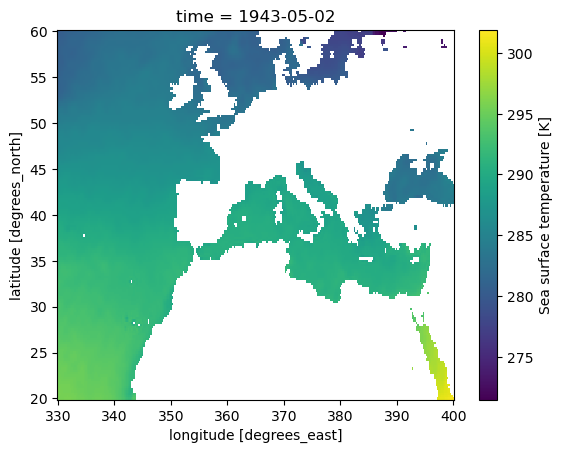

In [18]:
ds.SSTK.isel(time=0).plot()

:::{tip}
After `ncss.get_data(query)` returns, the subsetted response is loaded into local memory as a `netCDF4.Dataset` object. At that point, data has been loaded to the local memory; any further operations are performed on the locally received data.
:::

## CDMRemote Access

CDMRemote provides efficient remote access to the full dataset structure without downloading the entire file. Unlike NCSS which returns a spatial/temporal subset of actual data, CDMRemote exposes the complete Common Data Model (CDM) hierarchy of a dataset, allowing you to:

- Browse the full dataset structure and metadata
- Access specific variables and dimensions on-demand
- Query array-level data directly from the server
- Work with large datasets without local storage constraints

This is particularly useful when you need flexibility to explore different parts of a dataset or when you only have intermittent access to specific array slices.

In [19]:
# access via CDMRemote
remote_ds = target_ds.remote_access()
print(remote_ds)

https://tds.gdex.ucar.edu/thredds/cdmremote/files/g/d633000/e5.oper.an.sfc/194305/e5.oper.an.sfc.128_034_sstk.ll025sc.1943050100_1943053123.nc
Dimensions:
<class 'siphon.cdmr.dataset.Dimension'> name = latitude, size = 721
<class 'siphon.cdmr.dataset.Dimension'> name = longitude, size = 1440
<class 'siphon.cdmr.dataset.Dimension'> (unlimited): name = time, size = 744
Variables:
<class 'siphon.cdmr.dataset.Variable'>
float32 SSTK(time, latitude, longitude)
	long_name: Sea surface temperature
	short_name: sstk
	units: K
	original_format: WMO GRIB 1 with ECMWF local table
	ecmwf_local_table: 128
	ecmwf_parameter: 34
	_FillValue: 9.999000260554009e+20
	missing_value: 9.999000260554009e+20
	minimum_value: 270.85400390625
	maximum_value: 309.692138671875
	grid_specification: 0.25 degree x 0.25 degree from 90N to 90S and 0E to 359.75E (721 x 1440 Latitude/Longitude)
	rda_dataset: ds633.0
	rda_dataset_url: https:/rda.ucar.edu/datasets/ds633.0/
	rda_dataset_doi: DOI: 10.5065/BH6N-5N20
	rda_data

:::{tip}
**Use service metadata to plan your request**

CDMRemote/NCSS metadata is a reliable way to inspect dataset structure **before** subsetting.  
It exposes the available variables, dimensions, and sizes (for example, full `time`, `latitude`, and `longitude` ranges), which helps you choose valid bounds for an NCSS query.

It also confirms the exact variable name to request. In this case, the query must use **`SSTK`** (uppercase), which is not always obvious from the filename or THREDDS catalog page alone.
:::

---

## Summary

Siphon provides a Pythonic interface to GDEX THREDDS services. NCSS is ideal for pulling targeted subsets; CDMRemote gives full dataset access without a local download.

### What's next?

See `tds_xarray.ipynb` to open TDS data via OPeNDAP directly in xarray.

## Resources and References

- [Siphon documentation](https://unidata.github.io/siphon/latest/index.html)
- [Unidata Python Workshop — Siphon](https://unidata.github.io/python-training/)
- [GDEX THREDDS Catalog](https://thredds.rda.ucar.edu/thredds/catalog.html)